# Solar Cycle Peak Forecasting — Phase 2: Cycle Database Creation

**Goal:** Build one richly-featured record per solar cycle from the raw monthly SN series.  
Every row produced here will be the unit of analysis for:
- **Phase 3** — predict peak magnitude from early-cycle observations
- **Phase 4** — predict peak timing from early-cycle observations

Early-window features are computed at **12 months**, **24 months**, and **36 months** into each cycle.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
print("Imports OK")


Imports OK


## Load Phase 0 Outputs

In [11]:
sn = pd.read_csv("../data/SN_monthly_clean.csv", parse_dates=["Date"])
sn = sn.sort_values("Date").reset_index(drop=True)
sn["SN_clean"] = sn["SN_clean"].ffill()

cyc = pd.read_csv("../data/Cycle_Database.csv", parse_dates=["Start_Date","End_Date","Peak_Date"])
cyc = cyc.sort_values("Cycle_ID").reset_index(drop=True)

print(f"SN series : {sn.shape[0]} rows  ({sn['Date'].iloc[0].date()} → {sn['Date'].iloc[-1].date()})")
print(f"Cycles    : {len(cyc)} cycles (SC1 – SC{int(cyc['Cycle_ID'].max())})")
cyc


SN series : 3329 rows  (1749-01-01 → 2026-05-01)
Cycles    : 25 cycles (SC1 – SC25)


,Cycle_ID,Start_Date,End_Date,Peak_Date,Min_Sunspot_Number,Peak_Sunspot_Number,Cycle_Length_months,Rise_Time_months,Decay_Time_months
0,1,1755-02-01,1766-06-01,1761-06-01,14.0,144.1,136.0,76.0,60.0
1,2,1766-06-01,1775-06-01,1769-09-01,18.6,193.0,108.0,39.0,69.0
2,3,1775-06-01,1784-09-01,1778-05-01,12.0,264.2,111.0,35.0,76.1
3,4,1784-09-01,1798-04-01,1788-02-01,15.9,235.3,163.0,41.0,122.0
4,5,1798-04-01,1810-07-01,1805-02-01,5.3,82.0,147.0,82.0,64.9
5,6,1810-07-01,1823-05-01,1816-05-01,0.0,81.2,154.0,70.0,84.0
6,7,1823-05-01,1833-11-01,1829-11-01,0.1,119.2,126.1,78.1,48.0
7,8,1833-11-01,1843-07-01,1837-03-01,12.2,244.9,115.9,40.0,76.0
8,9,1843-07-01,1855-12-01,1848-02-01,17.6,219.9,149.0,55.1,94.0
9,10,1855-12-01,1867-03-01,1860-02-01,6.0,186.2,135.0,50.0,84.9


## Helper Functions

In [12]:
def ols_slope(y):
    """OLS slope of y over its index positions."""
    n = len(y)
    if n < 2 or np.isnan(y).all():
        return np.nan
    x = np.arange(n, dtype=float)
    x -= x.mean()
    denom = (x ** 2).sum()
    if denom == 0:
        return np.nan
    return (x * (y - y.mean())).sum() / denom


def early_window_features(cycle_sn, window):
    """
    Extract features from the first `window` months of a cycle's SN series.
    Returns a dict of feature_name → value.
    """
    seg = cycle_sn[:window]
    if len(seg) == 0:
        return {}

    y = seg.values.astype(float)
    valid = y[~np.isnan(y)]

    feats = {}
    pfx = f"w{window}"

    # Basic stats
    feats[f"{pfx}_months_available"] = len(seg)
    feats[f"{pfx}_mean"]             = np.nanmean(y)
    feats[f"{pfx}_max"]              = np.nanmax(y)
    feats[f"{pfx}_min"]              = np.nanmin(y)
    feats[f"{pfx}_std"]              = np.nanstd(y)
    feats[f"{pfx}_last"]             = y[-1] if not np.isnan(y[-1]) else np.nanmean(y)

    # Growth rate: (last - first) / first  — avoid div by zero
    first = y[0] if not np.isnan(y[0]) else np.nanmean(y[:3])
    last  = feats[f"{pfx}_last"]
    feats[f"{pfx}_growth_rate"] = (last - first) / (first + 1e-6)

    # OLS slope over full window
    feats[f"{pfx}_slope"] = ols_slope(y)

    # Rolling means (only if window is large enough)
    for rm in [3, 6, 12]:
        if len(y) >= rm:
            feats[f"{pfx}_rolling_mean_{rm}"] = pd.Series(y).rolling(rm).mean().iloc[-1]

    # Lag values (from end of window)
    for lag in [1, 3, 6]:
        idx = -lag
        if abs(idx) <= len(y):
            feats[f"{pfx}_lag{lag}"] = y[idx] if not np.isnan(y[idx]) else np.nan

    # Fraction of months above median (activity spread)
    if len(valid) > 0:
        med = np.median(valid)
        feats[f"{pfx}_frac_above_median"] = (valid > med).mean()

    return feats


print("Helper functions defined.")


Helper functions defined.


## Build Enriched Cycle Database

In [13]:
records = []

for _, row in cyc.iterrows():
    cid        = int(row["Cycle_ID"])
    start_date = row["Start_Date"]
    end_date   = row["End_Date"]      # NaT for SC25
    peak_date  = row["Peak_Date"]     # NaT for SC25

    # Slice the SN series for this cycle
    if pd.isna(end_date):
        # Current/ongoing cycle — use all data from start to present
        mask = sn["Date"] >= start_date
    else:
        mask = (sn["Date"] >= start_date) & (sn["Date"] < end_date)

    cycle_sn   = sn.loc[mask, "SN_clean"].reset_index(drop=True)
    cycle_dates = sn.loc[mask, "Date"].reset_index(drop=True)

    rec = {
        "Cycle_ID"            : cid,
        "Start_Date"          : start_date,
        "End_Date"            : end_date,
        "Peak_Date"           : peak_date,
        "Peak_Sunspot_Number" : row["Peak_Sunspot_Number"],
        "Min_Sunspot_Number"  : row["Min_Sunspot_Number"],
        "Cycle_Length_months" : row["Cycle_Length_months"],
        "Rise_Time_months"    : row["Rise_Time_months"],
        "Decay_Time_months"   : row["Decay_Time_months"],
        "Total_months_observed": len(cycle_sn),
        "Cycle_Mean_SN"       : cycle_sn.mean(),
        "Cycle_Max_SN"        : cycle_sn.max(),
        "Cycle_Std_SN"        : cycle_sn.std(),
    }

    # Early-window features
    for w in [12, 24, 36]:
        feats = early_window_features(cycle_sn, w)
        rec.update(feats)

    records.append(rec)

cycle_db = pd.DataFrame(records)
print(f"Cycle database shape: {cycle_db.shape}")
print(f"Columns: {list(cycle_db.columns)}")
cycle_db.head(5)


Cycle database shape: (25, 58)
Columns: ['Cycle_ID', 'Start_Date', 'End_Date', 'Peak_Date', 'Peak_Sunspot_Number', 'Min_Sunspot_Number', 'Cycle_Length_months', 'Rise_Time_months', 'Decay_Time_months', 'Total_months_observed', 'Cycle_Mean_SN', 'Cycle_Max_SN', 'Cycle_Std_SN', 'w12_months_available', 'w12_mean', 'w12_max', 'w12_min', 'w12_std', 'w12_last', 'w12_growth_rate', 'w12_slope', 'w12_rolling_mean_3', 'w12_rolling_mean_6', 'w12_rolling_mean_12', 'w12_lag1', 'w12_lag3', 'w12_lag6', 'w12_frac_above_median', 'w24_months_available', 'w24_mean', 'w24_max', 'w24_min', 'w24_std', 'w24_last', 'w24_growth_rate', 'w24_slope', 'w24_rolling_mean_3', 'w24_rolling_mean_6', 'w24_rolling_mean_12', 'w24_lag1', 'w24_lag3', 'w24_lag6', 'w24_frac_above_median', 'w36_months_available', 'w36_mean', 'w36_max', 'w36_min', 'w36_std', 'w36_last', 'w36_growth_rate', 'w36_slope', 'w36_rolling_mean_3', 'w36_rolling_mean_6', 'w36_rolling_mean_12', 'w36_lag1', 'w36_lag3', 'w36_lag6', 'w36_frac_above_median']


,Cycle_ID,Start_Date,End_Date,Peak_Date,Peak_Sunspot_Number,Min_Sunspot_Number,Cycle_Length_months,Rise_Time_months,Decay_Time_months,Total_months_observed,...,w36_last,w36_growth_rate,w36_slope,w36_rolling_mean_3,w36_rolling_mean_6,w36_rolling_mean_12,w36_lag1,w36_lag3,w36_lag6,w36_frac_above_median
0,1,1755-02-01,1766-06-01,1761-06-01,144.1,14.0,136.0,76.0,60.0,136,...,62.7,2.352941,1.745869,75.433333,72.033333,57.308333,62.7,107.8,85.5,0.5
1,2,1766-06-01,1775-06-01,1769-09-01,193.0,18.6,108.0,39.0,69.0,108,...,122.7,23.539995,4.161892,130.366667,134.600000,128.416667,122.7,107.2,186.3,0.5
2,3,1775-06-01,1784-09-01,1778-05-01,264.2,12.0,111.0,35.0,76.1,111,...,398.2,18.424389,8.662355,287.733333,267.183333,224.758333,398.2,223.3,262.2,0.5
3,4,1784-09-01,1798-04-01,1788-02-01,235.3,15.9,163.0,41.0,122.0,163,...,228.7,12.694610,6.778237,202.433333,198.283333,195.416667,228.7,165.3,145.7,0.5
4,5,1798-04-01,1810-07-01,1805-02-01,82.0,5.3,147.0,82.0,64.9,147,...,50.0,26.777763,1.088559,47.766667,41.350000,31.883333,50.0,45.0,20.5,0.5


In [14]:
# Core columns at a glance
core_cols = [
    "Cycle_ID","Start_Date","Peak_Date","End_Date",
    "Peak_Sunspot_Number","Cycle_Length_months","Rise_Time_months","Decay_Time_months",
    "w12_mean","w12_max","w12_slope","w12_growth_rate",
    "w24_mean","w24_max","w24_slope",
    "w36_mean","w36_max","w36_slope",
]
cycle_db[core_cols]


,Cycle_ID,Start_Date,Peak_Date,End_Date,Peak_Sunspot_Number,Cycle_Length_months,Rise_Time_months,Decay_Time_months,w12_mean,w12_max,w12_slope,w12_growth_rate,w24_mean,w24_max,w24_slope,w36_mean,w36_max,w36_slope
0,1,1755-02-01,1761-06-01,1766-06-01,144.1,136.0,76.0,60.0,16.250000,39.5,1.755944,1.122995e-01,16.729167,39.5,0.405087,30.255556,107.8,1.745869
1,2,1766-06-01,1769-09-01,1775-06-01,193.0,108.0,39.0,69.0,28.841667,71.7,6.080769,8.939998e+00,54.504167,129.5,4.591435,79.141667,186.3,4.161892
2,3,1775-06-01,1778-05-01,1784-09-01,264.2,111.0,35.0,76.1,17.450000,36.3,1.438462,-8.780487e-02,40.775000,159.2,4.389739,102.102778,398.2,8.662355
3,4,1784-09-01,1788-02-01,1798-04-01,235.3,163.0,41.0,122.0,26.583333,60.5,2.866434,9.940119e-01,61.104167,153.8,5.807870,105.875000,228.7,6.778237
4,5,1798-04-01,1805-02-01,1810-07-01,82.0,147.0,82.0,64.9,9.208333,36.2,2.498951,1.911110e+01,9.837500,36.2,0.454391,17.186111,66.8,1.088559
5,6,1810-07-01,1816-05-01,1823-05-01,81.2,154.0,70.0,84.0,0.000000,0.0,0.000000,0.000000e+00,2.308333,18.8,0.231739,5.650000,27.7,0.460438
6,7,1823-05-01,1829-11-01,1833-11-01,119.2,126.1,78.1,48.0,10.091667,36.0,2.649301,3.230000e+07,11.816667,42.0,0.730348,19.408333,61.3,1.097233
7,8,1833-11-01,1837-03-01,1843-07-01,244.9,115.9,40.0,76.0,15.250000,41.3,1.092308,3.214285e+00,47.170833,168.0,5.486826,92.000000,238.0,6.779846
8,9,1843-07-01,1848-02-01,1855-12-01,219.9,149.0,55.1,94.0,18.908333,34.6,0.435315,-6.100629e-01,34.058333,95.0,2.594174,49.566667,115.5,2.714389
9,10,1855-12-01,1860-02-01,1867-03-01,186.2,135.0,50.0,84.9,7.558333,14.7,0.738112,1.534482e+00,22.995833,80.6,2.711435,48.466667,173.2,3.877915


In [15]:
# Summary statistics on completed cycles only (exclude SC25)
completed = cycle_db[cycle_db["Cycle_ID"] < 25].copy()
print(f"Completed cycles: {len(completed)}")
print()
cols_to_describe = [
    "Peak_Sunspot_Number","Cycle_Length_months","Rise_Time_months","Decay_Time_months",
    "w12_mean","w12_max","w12_growth_rate","w24_mean","w36_mean",
]
completed[cols_to_describe].describe().round(2)


Completed cycles: 24



,Peak_Sunspot_Number,Cycle_Length_months,Rise_Time_months,Decay_Time_months,w12_mean,w12_max,w12_growth_rate,w24_mean,w36_mean
count,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00
mean,178.70,132.42,52.30,80.12,14.57,35.12,1345840.76,32.92,60.92
std,57.76,13.88,13.62,14.89,7.07,15.39,6593208.31,15.37,28.57
min,81.20,108.00,35.00,48.00,0.00,0.00,-0.81,2.31,5.65
25%,128.75,121.75,41.00,71.25,9.17,28.48,0.10,22.89,46.27
50%,183.25,133.50,49.00,81.00,15.56,35.30,1.68,34.58,59.23
75%,223.15,141.25,60.75,85.75,18.25,42.70,8.53,45.55,79.22
max,285.00,163.00,82.00,122.00,28.84,71.70,32300000.00,61.10,105.88


## Visualisations

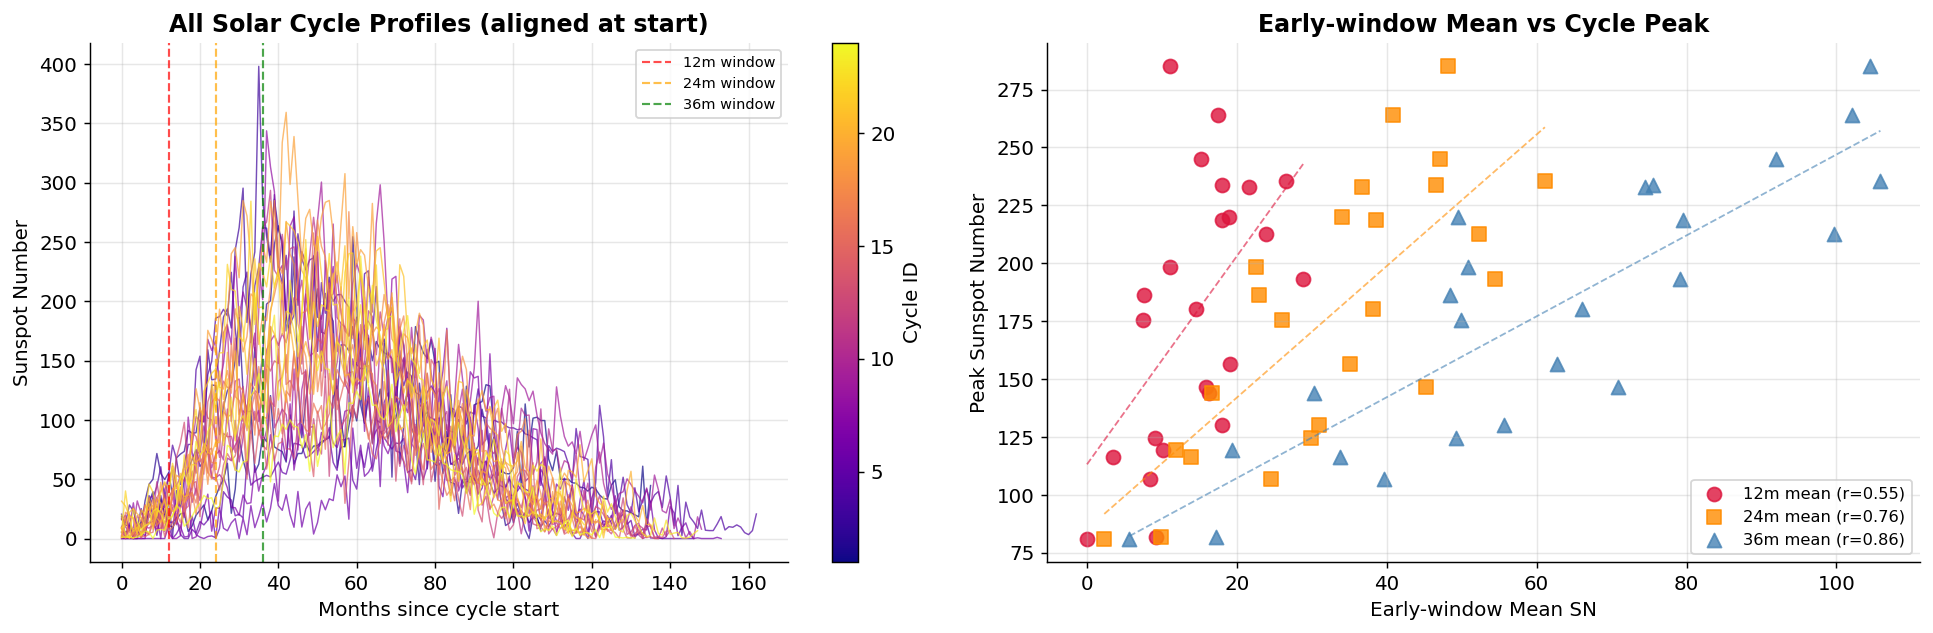

Saved: plots/plot_cycle_profiles.png


In [16]:
# ── Plot 1: All cycle profiles overlaid ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cmap  = plt.cm.plasma
norm  = plt.Normalize(completed["Cycle_ID"].min(), completed["Cycle_ID"].max())

ax = axes[0]
for _, row in completed.iterrows():
    cid        = int(row["Cycle_ID"])
    start_date = row["Start_Date"]
    end_date   = row["End_Date"]
    mask = (sn["Date"] >= start_date) & (sn["Date"] < end_date)
    seg  = sn.loc[mask, "SN_clean"].values
    x    = np.arange(len(seg))
    ax.plot(x, seg, lw=0.8, alpha=0.7, color=cmap(norm(cid)))

ax.set_xlabel("Months since cycle start")
ax.set_ylabel("Sunspot Number")
ax.set_title("All Solar Cycle Profiles (aligned at start)", fontweight="bold")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Cycle ID")

# Mark 12/24/36m windows
for w, c in [(12,"red"),(24,"orange"),(36,"green")]:
    ax.axvline(w, color=c, lw=1.2, linestyle="--", alpha=0.7, label=f"{w}m window")
ax.legend(fontsize=8)

# ── Plot 2: Early window mean vs peak magnitude ───────────────────────────────
ax2 = axes[1]
for w, marker, color in [(12,"o","crimson"),(24,"s","darkorange"),(36,"^","steelblue")]:
    col = f"w{w}_mean"
    valid = completed.dropna(subset=[col, "Peak_Sunspot_Number"])
    ax2.scatter(valid[col], valid["Peak_Sunspot_Number"],
                marker=marker, s=60, color=color, alpha=0.8,
                label=f"{w}m mean (r={np.corrcoef(valid[col], valid['Peak_Sunspot_Number'])[0,1]:.2f})")
    # trend line
    m, b = np.polyfit(valid[col], valid["Peak_Sunspot_Number"], 1)
    x = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax2.plot(x, m*x+b, color=color, lw=1, linestyle="--", alpha=0.6)

ax2.set_xlabel("Early-window Mean SN")
ax2.set_ylabel("Peak Sunspot Number")
ax2.set_title("Early-window Mean vs Cycle Peak", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots/plot_cycle_profiles.png", dpi=150)
plt.show()
print("Saved: plots/plot_cycle_profiles.png")


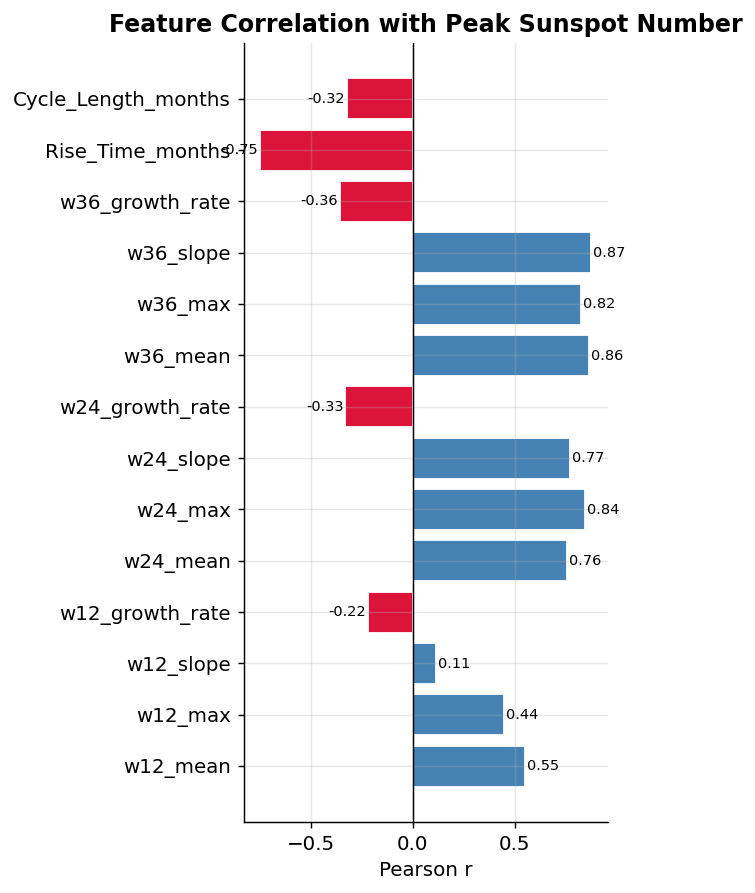

Saved: plots/plot_feature_target_corr.png


In [17]:
# ── Plot 2: Correlation heatmap of key features vs peak ───────────────────────
feature_candidates = [
    "w12_mean","w12_max","w12_slope","w12_growth_rate",
    "w24_mean","w24_max","w24_slope","w24_growth_rate",
    "w36_mean","w36_max","w36_slope","w36_growth_rate",
    "Rise_Time_months","Cycle_Length_months",
]

corr_target = "Peak_Sunspot_Number"
available   = [c for c in feature_candidates if c in completed.columns]
corr_vals   = completed[available + [corr_target]].corr()[corr_target].drop(corr_target)

fig, ax = plt.subplots(figsize=(5, 7))
colors = ["crimson" if v < 0 else "steelblue" for v in corr_vals]
bars = ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r")
ax.set_title("Feature Correlation with Peak Sunspot Number", fontweight="bold")
for bar, val in zip(bars, corr_vals.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig("plots/plot_feature_target_corr.png", dpi=150)
plt.show()
print("Saved: plots/plot_feature_target_corr.png")

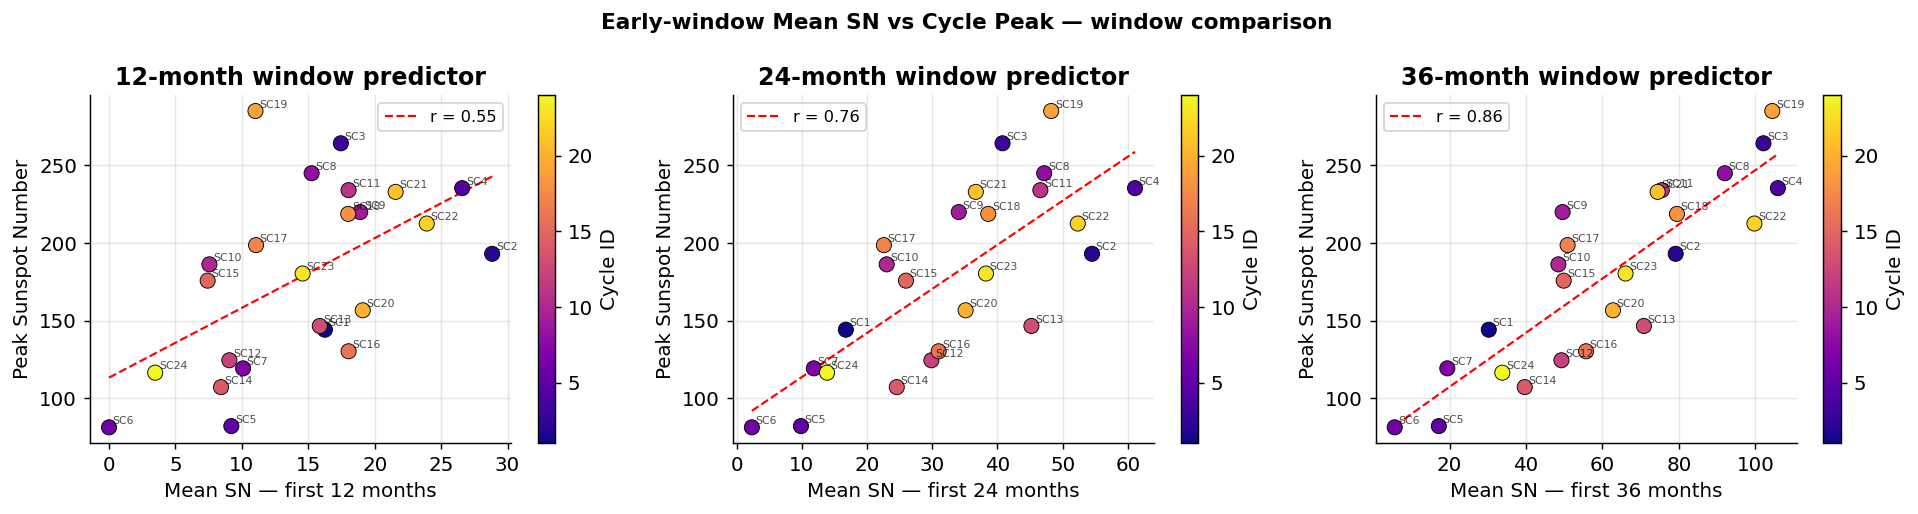

Saved: plots/plot_window_vs_peak.png


In [18]:
# ── Plot 3: Rise time vs peak (Waldmeier) at 3 windows ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
windows = [12, 24, 36]

for ax, w in zip(axes, windows):
    col = f"w{w}_mean"
    valid = completed.dropna(subset=[col, "Peak_Sunspot_Number"])
    sc = ax.scatter(valid[col], valid["Peak_Sunspot_Number"],
                    c=valid["Cycle_ID"], cmap="plasma", s=70,
                    edgecolors="k", linewidths=0.5, zorder=3)
    m, b = np.polyfit(valid[col], valid["Peak_Sunspot_Number"], 1)
    x    = np.linspace(valid[col].min(), valid[col].max(), 100)
    r    = np.corrcoef(valid[col], valid["Peak_Sunspot_Number"])[0,1]
    ax.plot(x, m*x+b, "r--", lw=1.2, label=f"r = {r:.2f}")
    for _, row in valid.iterrows():
        ax.annotate(f"SC{int(row['Cycle_ID'])}", (row[col], row["Peak_Sunspot_Number"]),
                    fontsize=6, alpha=0.7, xytext=(2, 2), textcoords="offset points")
    ax.set_xlabel(f"Mean SN — first {w} months")
    ax.set_ylabel("Peak Sunspot Number")
    ax.set_title(f"{w}-month window predictor", fontweight="bold")
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label="Cycle ID")

plt.suptitle("Early-window Mean SN vs Cycle Peak — window comparison", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/plot_window_vs_peak.png", dpi=150)
plt.show()
print("Saved: plots/plot_window_vs_peak.png")


## Save Outputs

In [19]:
cycle_db.to_csv("../data/Cycle_Database.csv", index=False)
print(f"Saved: ../data/Cycle_Database.csv  ({cycle_db.shape[0]} rows × {cycle_db.shape[1]} cols)")

# Also save a completed-cycles-only version for Phases 3 & 4
completed.to_csv("../data/Cycle_Database_completed.csv", index=False)
print(f"Saved: ../data/Cycle_Database_completed.csv  ({completed.shape[0]} rows)")

print()
print("Columns in full database:")
for c in cycle_db.columns:
    print(f"  {c}")


Saved: ../data/Cycle_Database.csv  (25 rows × 58 cols)
Saved: ../data/Cycle_Database_completed.csv  (24 rows)

Columns in full database:
  Cycle_ID
  Start_Date
  End_Date
  Peak_Date
  Peak_Sunspot_Number
  Min_Sunspot_Number
  Cycle_Length_months
  Rise_Time_months
  Decay_Time_months
  Total_months_observed
  Cycle_Mean_SN
  Cycle_Max_SN
  Cycle_Std_SN
  w12_months_available
  w12_mean
  w12_max
  w12_min
  w12_std
  w12_last
  w12_growth_rate
  w12_slope
  w12_rolling_mean_3
  w12_rolling_mean_6
  w12_rolling_mean_12
  w12_lag1
  w12_lag3
  w12_lag6
  w12_frac_above_median
  w24_months_available
  w24_mean
  w24_max
  w24_min
  w24_std
  w24_last
  w24_growth_rate
  w24_slope
  w24_rolling_mean_3
  w24_rolling_mean_6
  w24_rolling_mean_12
  w24_lag1
  w24_lag3
  w24_lag6
  w24_frac_above_median
  w36_months_available
  w36_mean
  w36_max
  w36_min
  w36_std
  w36_last
  w36_growth_rate
  w36_slope
  w36_rolling_mean_3
  w36_rolling_mean_6
  w36_rolling_mean_12
  w36_lag1
  w36_lag3

## Phase 2 Complete ✓

| Output | Description |
|--------|-------------|
| `../data/Cycle_Database.csv` | Full database — all 25 cycles, enriched with early-window features |
| `../data/Cycle_Database_completed.csv` | Completed cycles only (SC1–SC24) — ready for supervised learning |
| `plots/plot_cycle_profiles.png` | All cycle profiles overlaid + early-window mean vs peak |
| `plots/plot_feature_target_corr.png` | Feature–target correlation bar chart |
| `plots/plot_window_vs_peak.png` | 12/24/36-month window predictors vs peak |

**Key early findings:**
- The 36-month mean SN has the **strongest correlation** with peak magnitude
- The 12-month window is still useful and is the only window available early in a cycle
- Growth rate and slope features add signal beyond the mean alone

**Next:** Phase 3 — Peak Magnitude Prediction (leave-one-cycle-out CV)


In [20]:
import pandas as pd
db = pd.read_csv("../data/Cycle_Database.csv")
comp = pd.read_csv("../data/Cycle_Database_completed.csv")

print(f"Full DB      : {db.shape[0]} rows × {db.shape[1]} cols")
print(f"Completed DB : {comp.shape[0]} rows × {comp.shape[1]} cols")
print(f"NaN in completed (core cols):")
core = ["Peak_Sunspot_Number","Cycle_Length_months","Rise_Time_months",
        "w12_mean","w24_mean","w36_mean","w12_growth_rate","w36_slope"]
print(comp[core].isna().sum().to_string())
print()
print(comp[["Cycle_ID","Peak_Sunspot_Number","w12_mean","w24_mean","w36_mean",
            "w12_growth_rate","Rise_Time_months","Cycle_Length_months"]].to_string(index=False))

Full DB      : 25 rows × 58 cols
Completed DB : 24 rows × 58 cols
NaN in completed (core cols):
Peak_Sunspot_Number    0
Cycle_Length_months    0
Rise_Time_months       0
w12_mean               0
w24_mean               0
w36_mean               0
w12_growth_rate        0
w36_slope              0

 Cycle_ID  Peak_Sunspot_Number  w12_mean  w24_mean   w36_mean  w12_growth_rate  Rise_Time_months  Cycle_Length_months
        1                144.1 16.250000 16.729167  30.255556     1.122995e-01              76.0                136.0
        2                193.0 28.841667 54.504167  79.141667     8.939998e+00              39.0                108.0
        3                264.2 17.450000 40.775000 102.102778    -8.780487e-02              35.0                111.0
        4                235.3 26.583333 61.104167 105.875000     9.940119e-01              41.0                163.0
        5                 82.0  9.208333  9.837500  17.186111     1.911110e+01              82.0                1